In [1]:
import awkward as ak
import uproot
import numpy as np
import sklearn.metrics as m
import boost_histogram as bh
import glob
import os

from matplotlib import pyplot as plt
import matplotlib as mpl
from cycler import cycler
import mplhep as hep
plt.style.use(hep.style.CMS)

/afs/cern.ch/user/s/sewuchte/.local/lib/python3.10/site-packages/sklearn/utils/_param_validation.py:14: UserWarning: A NumPy version >=1.23.5 and <2.5.0 is required for this version of SciPy (detected version 1.23.4)
  from scipy.sparse import csr_matrix, issparse


In [2]:
# get the clors from mplhep
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
print (colors)

['#5790fc', '#f89c20', '#e42536', '#964a8b', '#9c9ca1', '#7a21dd']


In [9]:
def plotHLTAndOffline(variable_offline, variable_hlt, tree_offline, tree_hlt, year, xlabel = None, bins_ = None, outdir = "plots_scout_ak8/input_variables/"):
    # sam_title_map = {
    #     'QCD': 'QCD multijet',
    #     'TopWQCD': 't#bar{t} + W + QCD',
    #     'Signal': 'Signal (m_{Z\'}=3 TeV)',
    # }
    # label_dict = {
    #     'AK8': 'AK8 jets',
    #     'AK15': 'AK15 jets',
    # }
    # ptmin, ptmax = 500, 100000
    
    # read the variable from the trees, use ak.numexpr.evaluate to evaluate the variable expression such as 
    # df = df[ak.numexpr.evaluate(f"(scoutfj_pt>{ptmin}) & (scoutfj_pt<{ptmax}) & (abs(scoutfj_eta)<2.5)", df)]

    var_offline = ak.numexpr.evaluate(variable_offline, tree_offline)
    var_hlt = ak.numexpr.evaluate(variable_hlt, tree_hlt)

    # aply pt and eta selections
    sel_offline = (tree_offline['fj_pt'] > 200) & (tree_offline['fj_pt'] < 1500) & (abs(tree_offline['fj_eta']) < 2.5) & (tree_offline['fj_sdmass'] > 0)
    sel_hlt = (tree_hlt['scoutfj_pt'] > 200) & (tree_hlt['scoutfj_pt'] < 1500) & (abs(tree_hlt['scoutfj_eta']) < 2.5) & (tree_hlt['scoutfj_sdmass'] > 0)

    # apply general selection and only take jets with gen_mass = 125
    sel_offline = sel_offline & (tree_offline['fj_gen_mass'] == 125)
    sel_hlt = sel_hlt & (tree_hlt['scoutfj_gen_mass'] == 125)

    # and only bb decay
    sel_offline = sel_offline & (tree_offline['fj_label'] == 17)
    sel_hlt = sel_hlt & (tree_hlt['scoutfj_label'] == 17)

    var_offline_selected = var_offline[sel_offline]
    var_hlt_selected = var_hlt[sel_hlt]

    # flatten only if the variable is jagged, otherwise keep it as is
    if isinstance(var_offline_selected, ak.Array) and var_offline_selected.ndim > 1:
        var_offline_selected = ak.flatten(var_offline_selected)
        var_hlt_selected = ak.flatten(var_hlt_selected)

    # remove all 0.s wchich are dummy values
    var_offline_selected = var_offline_selected[(var_offline_selected > 0) | (var_offline_selected < 0)]  # keep negative values if they exist, but remove 0.s
    var_hlt_selected = var_hlt_selected[(var_hlt_selected > 0) | (var_hlt_selected < 0)]  # keep negative values if they exist, but remove 0.s

    ## Set up figure and axes
    f = plt.figure(figsize=(10, 10))

    plt.tight_layout()
    gs = f.add_gridspec(2, 1, height_ratios=[3,1], hspace=0.05)
    
    ## Upper histogram panel
    ax = f.add_subplot(gs[0])
    com = '13.6' if any(y in year for y in ['2022', '2023', '2024', '2025']) else '13'
    hep.cms.label(llabel = "Simulation Preliminary", rlabel=f'{year} ({com} TeV)', ax=ax, fontname='sans-serif')


    # Plot normalized histograms for offline and HLT such that the integral is 1
    # bins = np.linspace(0, 300, 31)  # Adjust bins as needed
    content_offline_orig, edges = np.histogram(var_offline_selected, bins=bins_, density=False)
    content_hlt_orig, _ = np.histogram(var_hlt_selected, bins=bins_, density=False)
    int_offline = np.sum(content_offline_orig)
    int_hlt = np.sum(content_hlt_orig)
    content_offline = content_offline_orig / int_offline
    content_hlt = content_hlt_orig / int_hlt
    yerr_offline = np.sqrt(content_offline_orig) / int_offline
    yerr_hlt = np.sqrt(content_hlt_orig) / int_hlt
    hep.histplot(content_offline, bins=edges, yerr=yerr_offline,  color='blue', label='Offline jets')
    hep.histplot(content_hlt, bins=edges, yerr=yerr_hlt, color='red', label='HLT scouting jets')

    ax.legend(loc='upper right', labelspacing=0.8, prop={'size': 18})
    # ax.set_xlabel(xlabel, ha='right', x=1.0); ax.set_ylabel('Jets / bin', ha='right', y=1.0);
    ax.set_xlim(bins_[0], bins_[-1])
    ax.set_ylim(0, ax.get_ylim()[1]*1.4)
    # no x labels here
    ax.set_xticklabels([])
    # a.u. y label
    ax.set_ylabel('A.U.', ha='right', y=1.0)

    # add some text and day this is Higgs to bb with mH=125 GeV
    ax.text(0.02, 0.95, 'H$\\rightarrow$bb ($m_{H,gen} = 125$ GeV)', transform=ax.transAxes, fontsize=15, verticalalignment='top')
    # add a selection plot for the eta and pt selection
    ax.text(0.02, 0.90, r'$200 < p_{T,j} < 1500$ GeV,  $|\eta_{j}|<2.5$, $m_{SD,j}$ > 0 GeV', transform=ax.transAxes, fontsize=12, verticalalignment='top')

    ## Ratio panel
    ax1 = f.add_subplot(gs[1])
    ratio = content_hlt / content_offline
    yerr_ratio = ratio * np.sqrt((yerr_hlt / content_hlt)**2 + (yerr_offline / content_offline)**2)
    hep.histplot(ratio, bins=edges, yerr=yerr_ratio, color='black', label='HLT / Offline')
    ax1.set_xlabel(xlabel, ha='right', x=1.0); ax1.set_ylabel('HLT / Offline', ha='center')
    ax1.set_xlim(bins_[0], bins_[-1])
    ax1.set_ylim(0.5, 1.5)
    ax1.plot([bins_[0], bins_[-1]], [1, 1], 'k--')  # Line at ratio=1
    plt.tight_layout()
    # plt.show()
    # now save the figure
    # outdir = 'plots_scout_ak8/input_variables/'
    os.makedirs(outdir, exist_ok=True)
    plt.savefig(f'{outdir}/HLT_vs_Offline_{variable_offline}_vs_{variable_hlt}_{year}.png')
    plt.savefig(f'{outdir}/HLT_vs_Offline_{variable_offline}_vs_{variable_hlt}_{year}.pdf')

    # plt.clf()

In [6]:
pathoffline = 'scouting_infer_ntuple_from_yyzhao/Hig_Low_mixed/dnnTuples*.root'  # Update with your path
pathhlt = 'scouting_infer_ntuple_from_yyzhao/Hig_Low_mixed/dnnTuples*.root'  # Update with your path
files_offline = glob.glob(pathoffline)
files_hlt = glob.glob(pathhlt)


tree_offline = uproot.concatenate(files_offline, num_workers=94)
print ("tree_offline has %d entries"%(len(tree_offline)))
tree_hlt = uproot.concatenate(files_hlt, num_workers=94)
print ("tree_hlt has %d entries"%(len(tree_hlt)))

tree_offline has 476192 entries
tree_hlt has 476192 entries


In [ ]:
plotHLTAndOffline('fj_pt', 'scoutfj_pt', tree_offline, tree_hlt, year='2024', xlabel = r'Jet $p_{T}$ (GeV)', bins_= np.linspace(200, 1500, 100), outdir = 'plots_scout_ak8/input_variables/')
plotHLTAndOffline('fj_eta', 'scoutfj_eta', tree_offline, tree_hlt, year='2024', xlabel = r'Jet $\eta$', bins_= np.linspace(-2.5, 2.5, 100), outdir = 'plots_scout_ak8/input_variables/')
plotHLTAndOffline('fj_sdmass', 'scoutfj_sdmass', tree_offline, tree_hlt, year='2024', xlabel = r'Jet $m_{SD}$ (GeV)', bins_= np.linspace(0, 200, 100), outdir = 'plots_scout_ak8/input_variables/')

In [ ]:
# plotHLTAndOffline('cpfcandlt_btagEtaRel', 'scoutpfcand_btagEtaRel', tree_offline, tree_hlt, year='2024', xlabel = r'btagEtaRel', bins_= np.linspace(0, 5, 100))
plotHLTAndOffline('cpfcandlt_dxysig', 'scoutpfcand_dxysig', tree_offline, tree_hlt, year='2024', xlabel = r'$d_{xy}$ significance', bins_= np.linspace(-5, 5, 100))
plotHLTAndOffline('cpfcandlt_dxy', 'scoutpfcand_dxy', tree_offline, tree_hlt, year='2024', xlabel = r'$d_{xy}$ [cm]', bins_= np.linspace(-0.03, 0.03, 100))
plotHLTAndOffline('cpfcandlt_dzsig', 'scoutpfcand_dzsig', tree_offline, tree_hlt, year='2024', xlabel = r'$d_{z}$ significance', bins_= np.linspace(-5, 5, 100))
plotHLTAndOffline('cpfcandlt_dz', 'scoutpfcand_dz', tree_offline, tree_hlt, year='2024', xlabel = r'$d_{z}$ [cm]', bins_= np.linspace(-0.03, 0.03, 100))
plotHLTAndOffline('cpfcandlt_e_log_nopuppi', 'scoutpfcand_e_log', tree_offline, tree_hlt, year='2024', xlabel = r'$log(E)$ [log(GeV)]', bins_= np.linspace(0, 5, 100))
plotHLTAndOffline('cpfcandlt_pt_log_nopuppi', 'scoutpfcand_pt_log', tree_offline, tree_hlt, year='2024', xlabel = r'$log(p_{T}/GeV)$ [log(GeV)]', bins_= np.linspace(0, 5, 100))
plotHLTAndOffline('cpfcandlt_phirel', 'scoutpfcand_phirel', tree_offline, tree_hlt, year='2024', xlabel = r'$\phi$ rel. to jet axis ($\Delata|phi$)', bins_= np.linspace(-0.8, 0.8, 100))
plotHLTAndOffline('cpfcandlt_etarel', 'scoutpfcand_etarel', tree_offline, tree_hlt, year='2024', xlabel = r'$\eta$ rel. to jet axis ()', bins_= np.linspace(-0.8, 0.8, 100))

In [7]:
pathoffline_23 = 'scouting_infer_ntuple_from_yyzhao/2023/BulkGravitonToHHTo4QGluLTau_MH-125_LowPt/dnntuple_nanov15_*-*.root'  # Update with your path
pathhlt_23 = 'scouting_infer_ntuple_from_yyzhao/2023/BulkGravitonToHHTo4QGluLTau_MH-125_LowPt/dnntuple_nanov15_*-*.root'  # Update with your path
files_offline_23 = glob.glob(pathoffline_23)
files_hlt_23 = glob.glob(pathhlt_23)


tree_offline_23 = uproot.concatenate(files_offline_23, num_workers=16)
print ("tree_offline_23 has %d entries"%(len(tree_offline_23)))
tree_hlt_23 = uproot.concatenate(files_hlt_23, num_workers=16)
print ("tree_hlt_23 has %d entries"%(len(tree_hlt_23)))

tree_offline_23 has 147659 entries
tree_hlt_23 has 147659 entries


In [ ]:
plotHLTAndOffline('fj_pt', 'scoutfj_pt', tree_offline_23, tree_hlt_23, year='2024', xlabel = r'Jet $p_{T}$ (GeV)', bins_= np.linspace(200, 1500, 100), outdir = 'plots_scout_ak8/input_variables_23/')
plotHLTAndOffline('fj_eta', 'scoutfj_eta', tree_offline_23, tree_hlt_23, year='2024', xlabel = r'Jet $\eta$', bins_= np.linspace(-2.5, 2.5, 100), outdir = 'plots_scout_ak8/input_variables_23/')
plotHLTAndOffline('fj_sdmass', 'scoutfj_sdmass', tree_offline_23, tree_hlt_23, year='2024', xlabel = r'Jet $m_{SD}$ (GeV)', bins_= np.linspace(0, 200, 100), outdir = 'plots_scout_ak8/input_variables_23/')

In [ ]:
# plotHLTAndOffline('cpfcandlt_btagEtaRel', 'scoutpfcand_btagEtaRel', tree_offline, tree_hlt, year='2024', xlabel = r'btagEtaRel', bins_= np.linspace(0, 5, 100))
plotHLTAndOffline('cpfcandlt_dxysig', 'scoutpfcand_dxysig', tree_offline_23, tree_hlt_23, year='2024', xlabel = r'$d_{xy}$ significance', bins_= np.linspace(-5, 5, 100), outdir= 'plots_scout_ak8/input_variables_23/')
plotHLTAndOffline('cpfcandlt_dxy', 'scoutpfcand_dxy', tree_offline_23, tree_hlt_23, year='2024', xlabel = r'$d_{xy}$ [cm]', bins_= np.linspace(-0.03, 0.03, 100), outdir= 'plots_scout_ak8/input_variables_23/')
plotHLTAndOffline('cpfcandlt_dzsig', 'scoutpfcand_dzsig', tree_offline_23, tree_hlt_23, year='2024', xlabel = r'$d_{z}$ significance', bins_= np.linspace(-5, 5, 100), outdir= 'plots_scout_ak8/input_variables_23/')
plotHLTAndOffline('cpfcandlt_dz', 'scoutpfcand_dz', tree_offline_23, tree_hlt_23, year='2024', xlabel = r'$d_{z}$ [cm]', bins_= np.linspace(-0.03, 0.03, 100), outdir= 'plots_scout_ak8/input_variables_23/')
plotHLTAndOffline('cpfcandlt_e_log_nopuppi', 'scoutpfcand_e_log', tree_offline_23, tree_hlt_23, year='2024', xlabel = r'$log(E)$ [log(GeV)]', bins_= np.linspace(0, 5, 100), outdir= 'plots_scout_ak8/input_variables_23/')
plotHLTAndOffline('cpfcandlt_pt_log_nopuppi', 'scoutpfcand_pt_log', tree_offline_23, tree_hlt_23, year='2024', xlabel = r'$log(p_{T})$ [log(GeV)]', bins_= np.linspace(0, 5, 100), outdir= 'plots_scout_ak8/input_variables_23/')
plotHLTAndOffline('cpfcandlt_phirel', 'scoutpfcand_phirel', tree_offline_23, tree_hlt_23, year='2024', xlabel = r'$\phi$ rel. to jet axis', bins_= np.linspace(-0.8, 0.8, 100), outdir= 'plots_scout_ak8/input_variables_23/')
plotHLTAndOffline('cpfcandlt_etarel', 'scoutpfcand_etarel', tree_offline_23, tree_hlt_23, year='2024', xlabel = r'$\eta$ rel. to jet axis', bins_= np.linspace(-0.8, 0.8, 100), outdir= 'plots_scout_ak8/input_variables_23/')

In [47]:
def plotHLTAndOffline4(variable_offline, variable_hlt, tree_offline, tree_hlt, tree_offline2, tree_hlt2, year, xlabel = None, bins_ = None, outdir = "plots_scout_ak8/input_variables/"):
    # sam_title_map = {
    #     'QCD': 'QCD multijet',
    #     'TopWQCD': 't#bar{t} + W + QCD',
    #     'Signal': 'Signal (m_{Z\'}=3 TeV)',
    # }
    # label_dict = {
    #     'AK8': 'AK8 jets',
    #     'AK15': 'AK15 jets',
    # }
    # ptmin, ptmax = 500, 100000
    
    # read the variable from the trees, use ak.numexpr.evaluate to evaluate the variable expression such as 
    # df = df[ak.numexpr.evaluate(f"(scoutfj_pt>{ptmin}) & (scoutfj_pt<{ptmax}) & (abs(scoutfj_eta)<2.5)", df)]

    var_offline = ak.numexpr.evaluate(variable_offline, tree_offline)
    var_offline2 = ak.numexpr.evaluate(variable_offline, tree_offline2)
    var_hlt = ak.numexpr.evaluate(variable_hlt, tree_hlt)
    var_hlt2 = ak.numexpr.evaluate(variable_hlt, tree_hlt2)


    # aply pt and eta selections
    sel_offline = (tree_offline['fj_pt'] > 200) & (tree_offline['fj_pt'] < 1500) & (abs(tree_offline['fj_eta']) < 2.5) & (tree_offline['fj_sdmass'] > 20)
    sel_offline2 = (tree_offline2['fj_pt'] > 200) & (tree_offline2['fj_pt'] < 1500) & (abs(tree_offline2['fj_eta']) < 2.5) & (tree_offline2['fj_sdmass'] > 20)
    sel_hlt = (tree_hlt['scoutfj_pt'] > 200) & (tree_hlt['scoutfj_pt'] < 1500) & (abs(tree_hlt['scoutfj_eta']) < 2.5) & (tree_hlt['scoutfj_sdmass'] > 20)
    sel_hlt2 = (tree_hlt2['scoutfj_pt'] > 200) & (tree_hlt2['scoutfj_pt'] < 1500) & (abs(tree_hlt2['scoutfj_eta']) < 2.5) & (tree_hlt2['scoutfj_sdmass'] > 20)

    # apply general selection and only take jets with gen_mass = 125
    sel_offline = sel_offline & (tree_offline['fj_gen_mass'] == 125)
    sel_offline2 = sel_offline2 & (tree_offline2['fj_gen_mass'] == 125)
    sel_hlt2 = sel_hlt2 & (tree_hlt2['scoutfj_gen_mass'] == 125)
    sel_hlt = sel_hlt & (tree_hlt['scoutfj_gen_mass'] == 125)

    # and only bb decay
    sel_offline = sel_offline & (tree_offline['fj_label'] == 17)
    sel_offline2 = sel_offline2 & (tree_offline2['fj_label'] == 17)
    sel_hlt = sel_hlt & (tree_hlt['scoutfj_label'] == 17)
    sel_hlt2 = sel_hlt2 & (tree_hlt2['scoutfj_label'] == 17)

    var_offline_selected = var_offline[sel_offline]
    var_offline_selected2 = var_offline2[sel_offline2]
    var_hlt_selected = var_hlt[sel_hlt]
    var_hlt_selected2 = var_hlt2[sel_hlt2]

    # flatten only if the variable is jagged, otherwise keep it as is
    if isinstance(var_offline_selected, ak.Array) and var_offline_selected.ndim > 1:
        var_offline_selected = ak.flatten(var_offline_selected)
        var_offline_selected2 = ak.flatten(var_offline_selected2)
        var_hlt_selected = ak.flatten(var_hlt_selected)
        var_hlt_selected2 = ak.flatten(var_hlt_selected2)



    # if 'e_log' in variable_hlt:
    #     print ("Applying eta cut for e_log variable")
    #     var_abseta = ak.numexpr.evaluate("scoutpfcand_abseta", tree_hlt2)
    #     var_abseta_sel = var_abseta[sel_hlt2]
    #     var_abseta_flat = ak.flatten(var_abseta_sel)
    #     # sel_hlt2 = (abs(tree_hlt2['scoutpfcand_abseta']) < 1.6) | (abs(tree_hlt2['scoutpfcand_abseta']) > 1.8)
    #     # now we cut var_hlt_selected2 with var_abseta_flat
    #     var_hlt_selected2 = var_hlt_selected2[(var_abseta_flat < 1.4) | (var_abseta_flat > 1.8)]

    # remove all 0.s wchich are dummy values
    var_offline_selected = var_offline_selected[(var_offline_selected > 0) | (var_offline_selected < 0)]  # keep negative values if they exist, but remove 0.s
    var_offline_selected2 = var_offline_selected2[(var_offline_selected2 > 0) | (var_offline_selected2 < 0)]  # keep negative values if they exist, but remove 0.s
    var_hlt_selected = var_hlt_selected[(var_hlt_selected > 0) | (var_hlt_selected < 0)]  # keep negative values if they exist, but remove 0.s
    var_hlt_selected2 = var_hlt_selected2[(var_hlt_selected2 > 0) | (var_hlt_selected2 < 0)]  # keep negative values if they exist, but remove 0

    ## Set up figure and axes
    f = plt.figure(figsize=(12, 12), layout="constrained")

    # plt.tight_layout()
    gs = f.add_gridspec(2, 1, height_ratios=[3,1], hspace=0.05)
    
    ## Upper histogram panel
    ax = f.add_subplot(gs[0])
    com = '13.6' if any(y in year for y in ['2022', '2023', '2024', '2025']) else '13'
    # hep.cms.label(llabel = "Simulation Preliminary", rlabel=f'{year} ({com} TeV)', ax=ax, fontname='sans-serif')
    # hep.cms.label(llabel = "Simulation Preliminary", rlabel=f'2023+2024 ({com} TeV)', ax=ax, fontname='sans-serif')
    hep.cms.label(llabel = "Simulation Preliminary", rlabel=f'{com} TeV', ax=ax, fontname='sans-serif', fontsize=33)


    # Plot normalized histograms for offline and HLT such that the integral is 1
    # bins = np.linspace(0, 300, 31)  # Adjust bins as needed
    content_offline_orig, edges = np.histogram(var_offline_selected, bins=bins_, density=False)
    content_offline_orig2, _ = np.histogram(var_offline_selected2, bins=bins_, density=False)
    content_hlt_orig, _ = np.histogram(var_hlt_selected, bins=bins_, density=False)
    content_hlt_orig2, _ = np.histogram(var_hlt_selected2, bins=bins_, density=False)
    int_offline = np.sum(content_offline_orig)
    int_offline2 = np.sum(content_offline_orig2)
    int_hlt = np.sum(content_hlt_orig)
    int_hlt2 = np.sum(content_hlt_orig2)
    content_offline = content_offline_orig / int_offline
    content_offline2 = content_offline_orig2 / int_offline2
    content_hlt = content_hlt_orig / int_hlt
    content_hlt2 = content_hlt_orig2 / int_hlt2
    yerr_offline = np.sqrt(content_offline_orig) / int_offline
    yerr_offline2 = np.sqrt(content_offline_orig2) / int_offline2
    yerr_hlt = np.sqrt(content_hlt_orig) / int_hlt
    yerr_hlt2 = np.sqrt(content_hlt_orig2) / int_hlt2
    hep.histplot(content_offline, bins=edges, yerr=yerr_offline,  color=colors[0], label='Offline', linewidth=2)
    # hep.histplot(content_offline2, bins=edges, yerr=yerr_offline2,  color='green', label='Offline jets 2')
    hep.histplot(content_hlt, bins=edges, yerr=yerr_hlt, color=colors[1], label='Full tracking (2024)', linewidth=2)
    hep.histplot(content_hlt2, bins=edges, yerr=yerr_hlt2, color=colors[2], label='Pixel-only tracking (2023)', linewidth=2)

    # ax.legend(loc='upper right', labelspacing=0.8, prop={'size': 18})
    ax.legend(loc='upper right', labelspacing=0.8, prop={'size': 27})
    # ax.set_xlabel(xlabel, ha='right', x=1.0); ax.set_ylabel('Jets / bin', ha='right', y=1.0);
    ax.set_xlim(bins_[0], bins_[-1])
    ax.set_ylim(0, ax.get_ylim()[1]*1.4)
    # no x labels here
    ax.set_xticklabels([])
    # a.u. y label
    ax.set_ylabel('A.U.', ha='right', y=1.0, fontsize=33)
    # set x and y labels fontsize
    

    # add some text and day this is Higgs to bb with mH=125 GeV
    ax.text(0.02, 0.95, 'H$\\rightarrow$bb ($m_{H,gen} = 125$ GeV)', transform=ax.transAxes, verticalalignment='top', fontsize=23)
    # add a selection plot for the eta and pt selection
    ax.text(0.02, 0.89, r'$200 < p_{T,j} < 1500$ GeV', transform=ax.transAxes, verticalalignment='top', fontsize=20)
    ax.text(0.02, 0.84, r'$|\eta_{j}|<2.5$, $m_{SD,j}$ > 20 GeV', transform=ax.transAxes, verticalalignment='top', fontsize=20)

    ## Ratio panel
    ax1 = f.add_subplot(gs[1])
    ratio = content_hlt / content_offline
    ratio2 = content_hlt2 / content_offline
    ratio3 = content_offline2 / content_offline
    yerr_ratio = ratio * np.sqrt((yerr_hlt / content_hlt)**2 + (yerr_offline / content_offline)**2)
    yerr_ratio2 = ratio2 * np.sqrt((yerr_hlt / content_hlt2)**2 + (yerr_offline2 / content_offline2)**2)
    yerr_ratio3 = ratio3 * np.sqrt((yerr_offline2 / content_offline2)**2 + (yerr_offline / content_offline)**2)
    hep.histplot(ratio, bins=edges, yerr=yerr_ratio, color=colors[1], label='2024', linewidth=2)
    hep.histplot(ratio2, bins=edges, yerr=yerr_ratio2, color=colors[2], label='2023', linewidth=2)
    # hep.histplot(ratio3, bins=edges, yerr=yerr_ratio3, color='green', label='Offline 2 / Offline')
    # ax1.legend(loc='upper left', labelspacing=0.8, prop={'size': 22})
    ax1.legend(loc='best', labelspacing=0.1, prop={'size': 27}, ncols = 2)
    ax1.set_xlabel(xlabel, ha='right', x=1.0, fontsize=33)
    ax1.set_ylabel('Scouting / Offline', ha='center', fontsize=33)
    ax1.set_xlim(bins_[0], bins_[-1])
    ax1.set_ylim(0.5, 1.5)
    ax1.plot([bins_[0], bins_[-1]], [1, 1], 'k--')  # Line at ratio=1
    # plt.tight_layout()
    # plt.show()
    # now save the figure
    # outdir = 'plots_scout_ak8/input_variables/'
    os.makedirs(outdir, exist_ok=True)
    plt.savefig(f'{outdir}/HLT_vs_Offline_{variable_offline}_vs_{variable_hlt}_{year}.png')
    plt.savefig(f'{outdir}/HLT_vs_Offline_{variable_offline}_vs_{variable_hlt}_{year}.pdf')

    # plt.clf()

/eos/home-s/sewuchte/MyConda/envs/weaver_glopart/lib/python3.10/site-packages/awkward/_nplikes/array_module.py:311: RuntimeWarning: invalid value encountered in divide
  return impl(*non_generic_value_promoted_args, **(kwargs or {}))


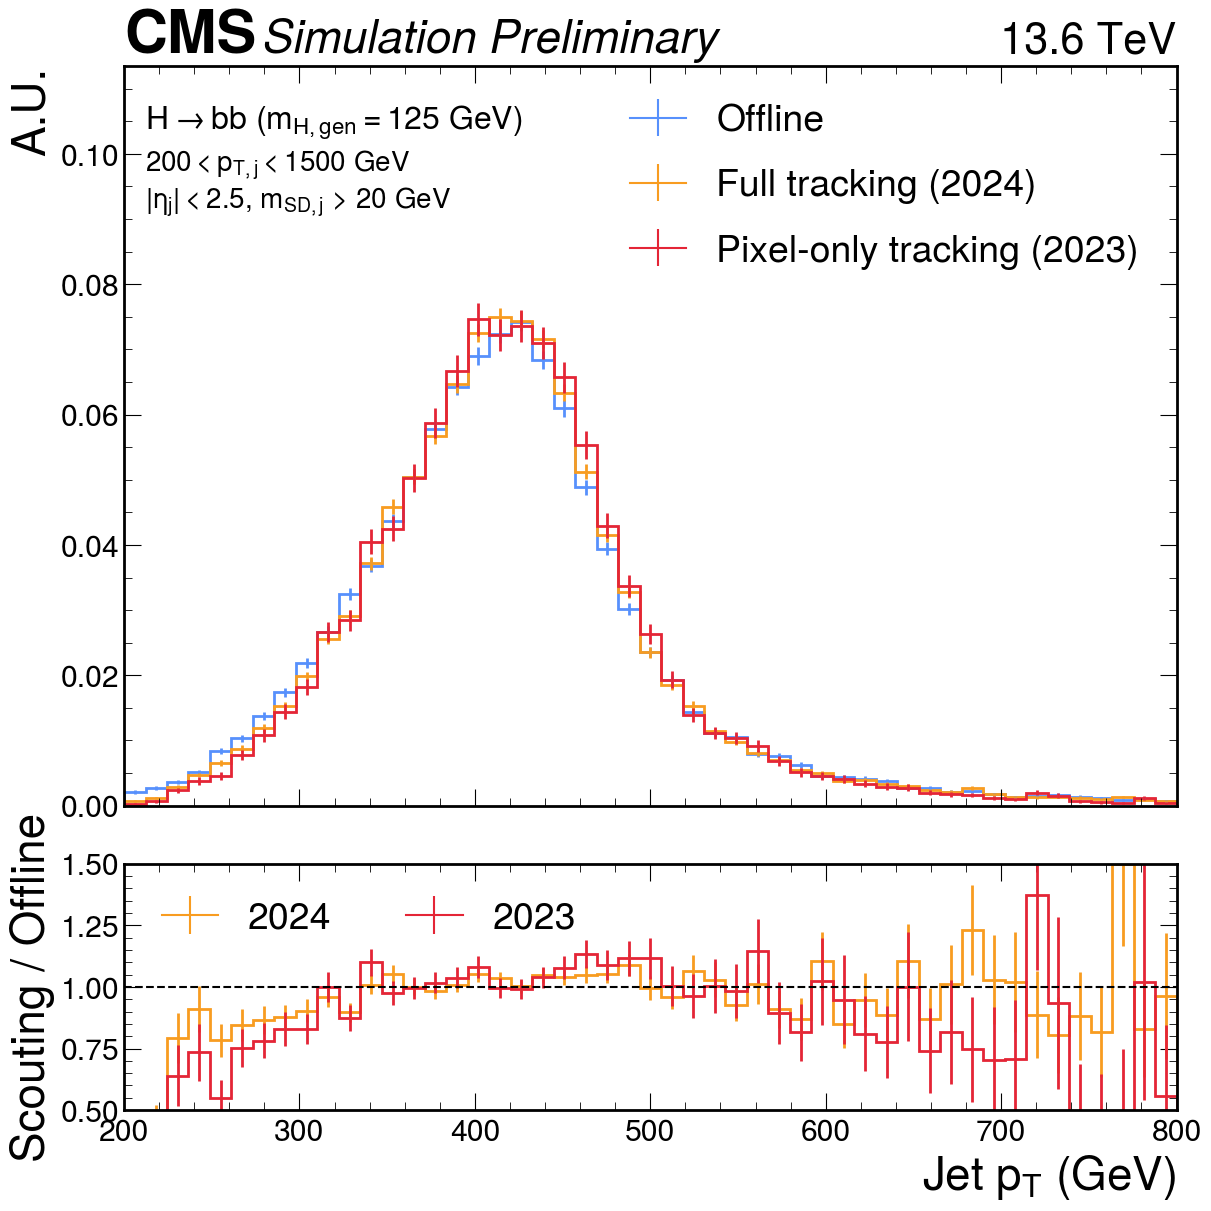

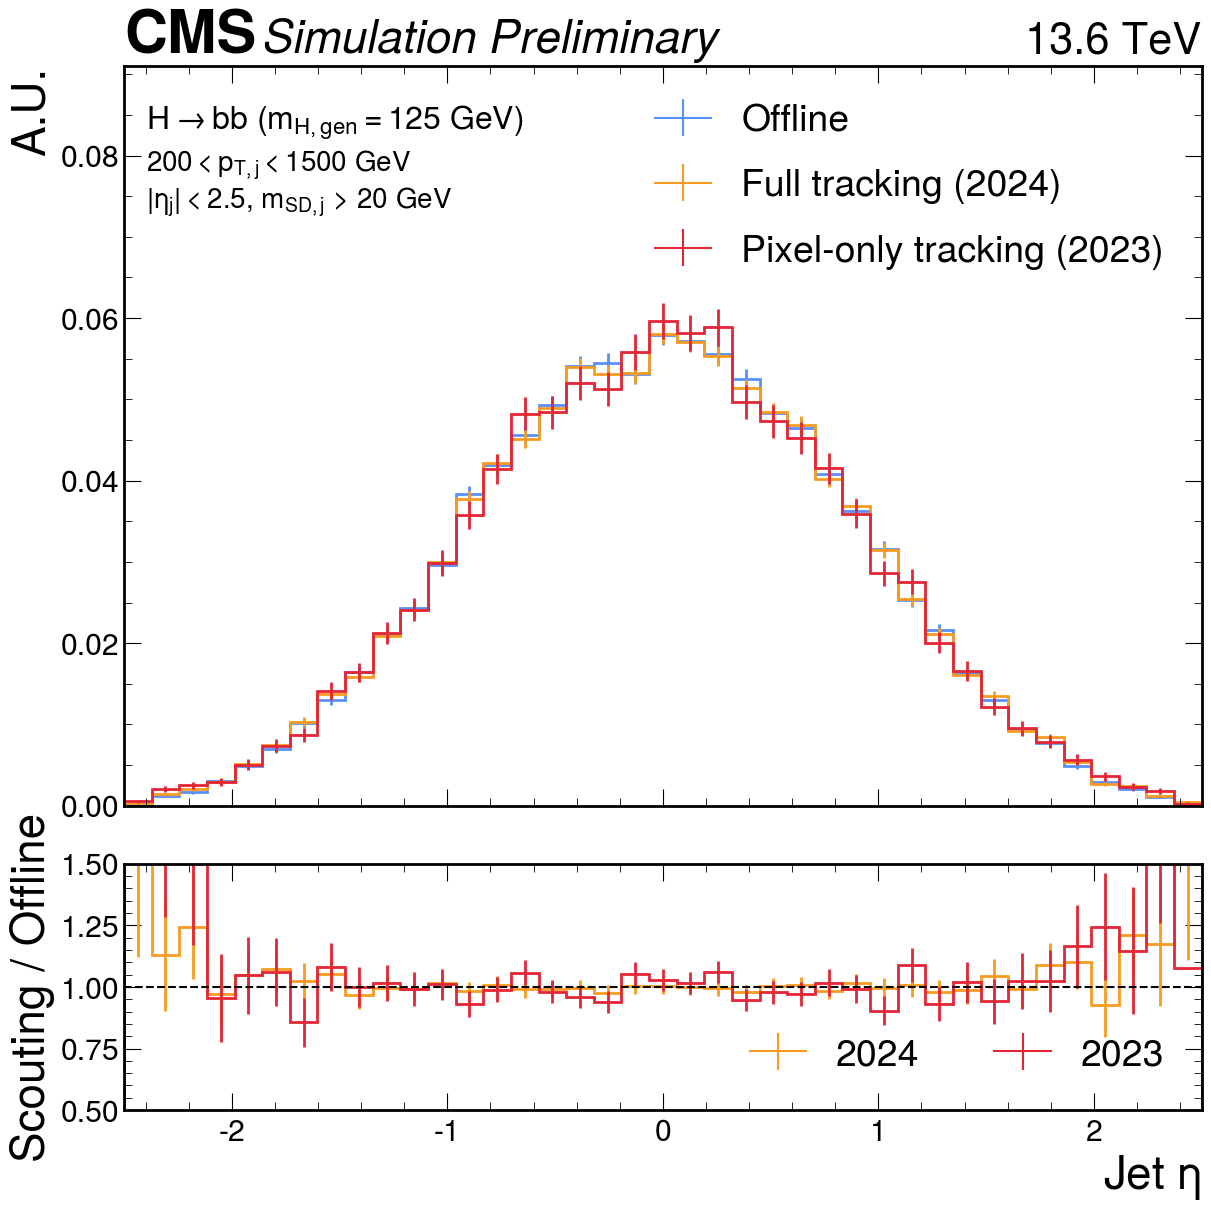

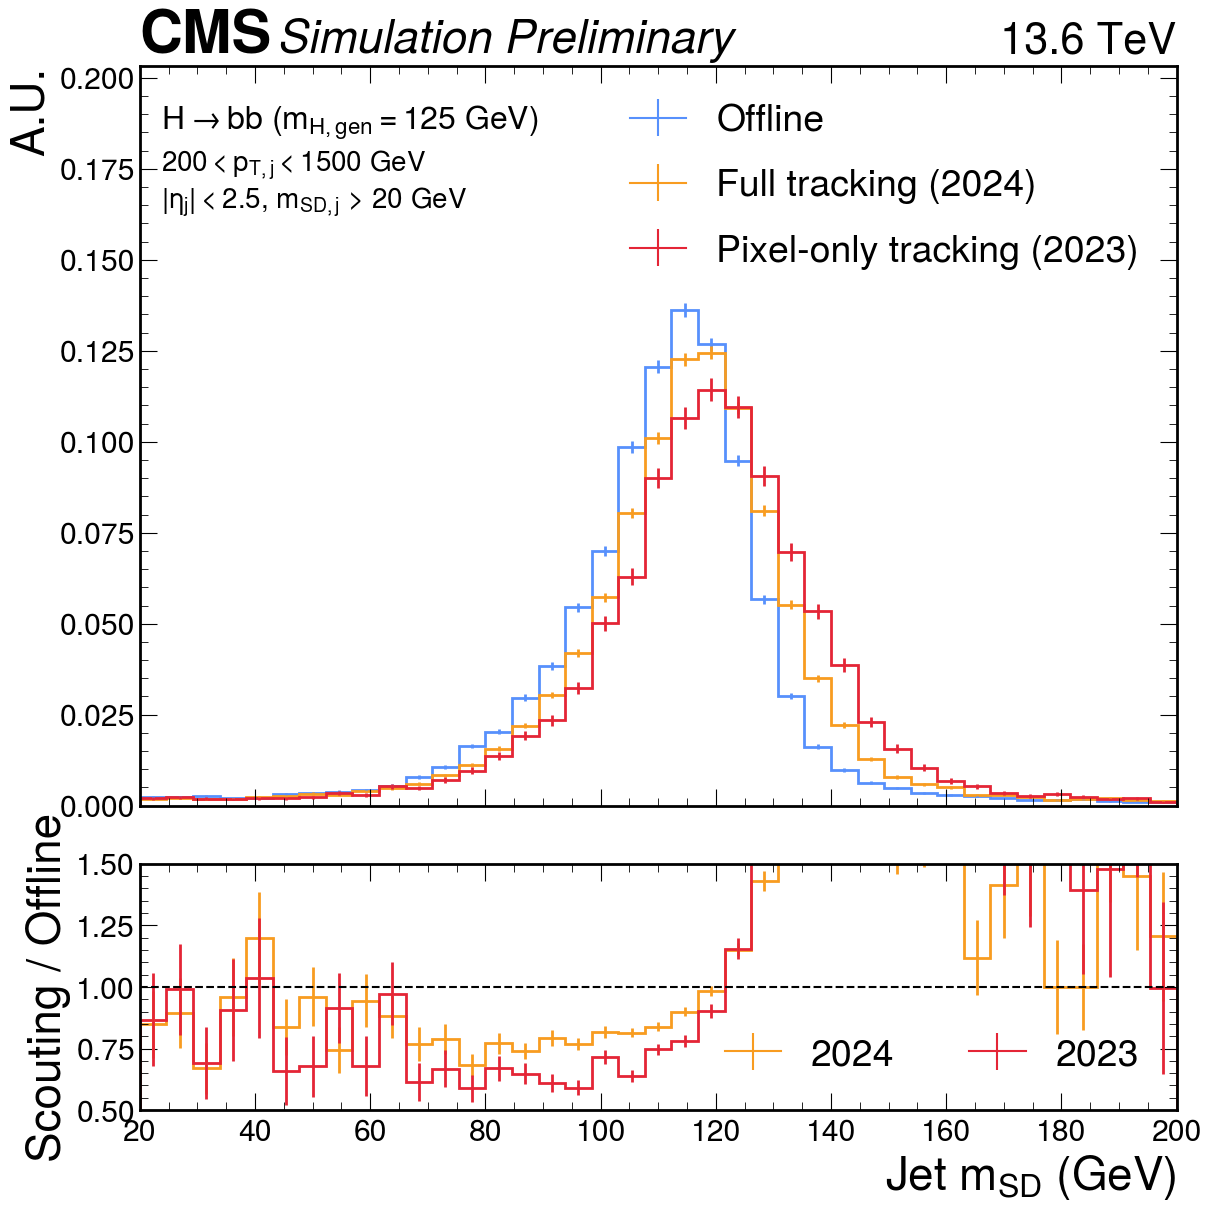

In [48]:
# plotHLTAndOffline4('fj_pt', 'scoutfj_pt', tree_offline, tree_hlt, tree_offline_23, tree_hlt_23, year='2024', xlabel = r'Jet $p_{T}$ (GeV)', bins_= np.linspace(200, 1500, 50), outdir = 'plots_scout_ak8/input_variables_23_trial/')
plotHLTAndOffline4('fj_pt', 'scoutfj_pt', tree_offline, tree_hlt, tree_offline_23, tree_hlt_23, year='2024', xlabel = r'Jet $p_{T}$ (GeV)', bins_= np.linspace(200, 800, 50), outdir = 'plots_scout_ak8/input_variables_23_trial/')
plotHLTAndOffline4('fj_eta', 'scoutfj_eta', tree_offline, tree_hlt, tree_offline_23, tree_hlt_23, year='2024', xlabel = r'Jet $\eta$', bins_= np.linspace(-2.5, 2.5, 40), outdir = 'plots_scout_ak8/input_variables_23_trial/')
plotHLTAndOffline4('fj_sdmass', 'scoutfj_sdmass', tree_offline, tree_hlt, tree_offline_23, tree_hlt_23, year='2024', xlabel = r'Jet $m_{SD}$ (GeV)', bins_= np.linspace(20, 200, 40), outdir = 'plots_scout_ak8/input_variables_23_trial/')



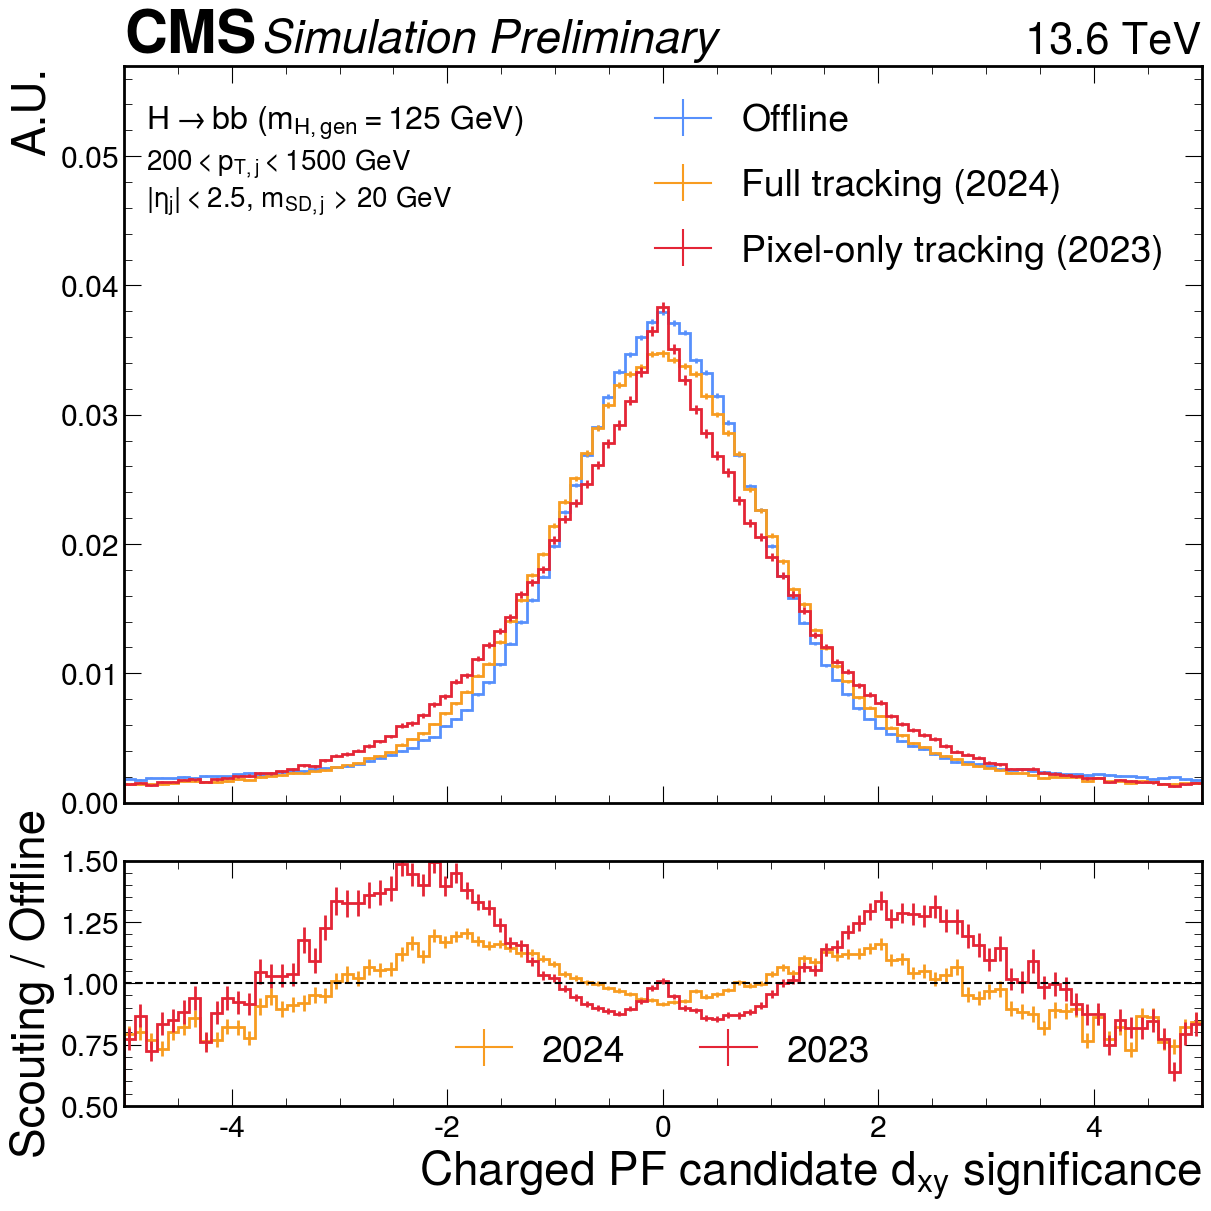

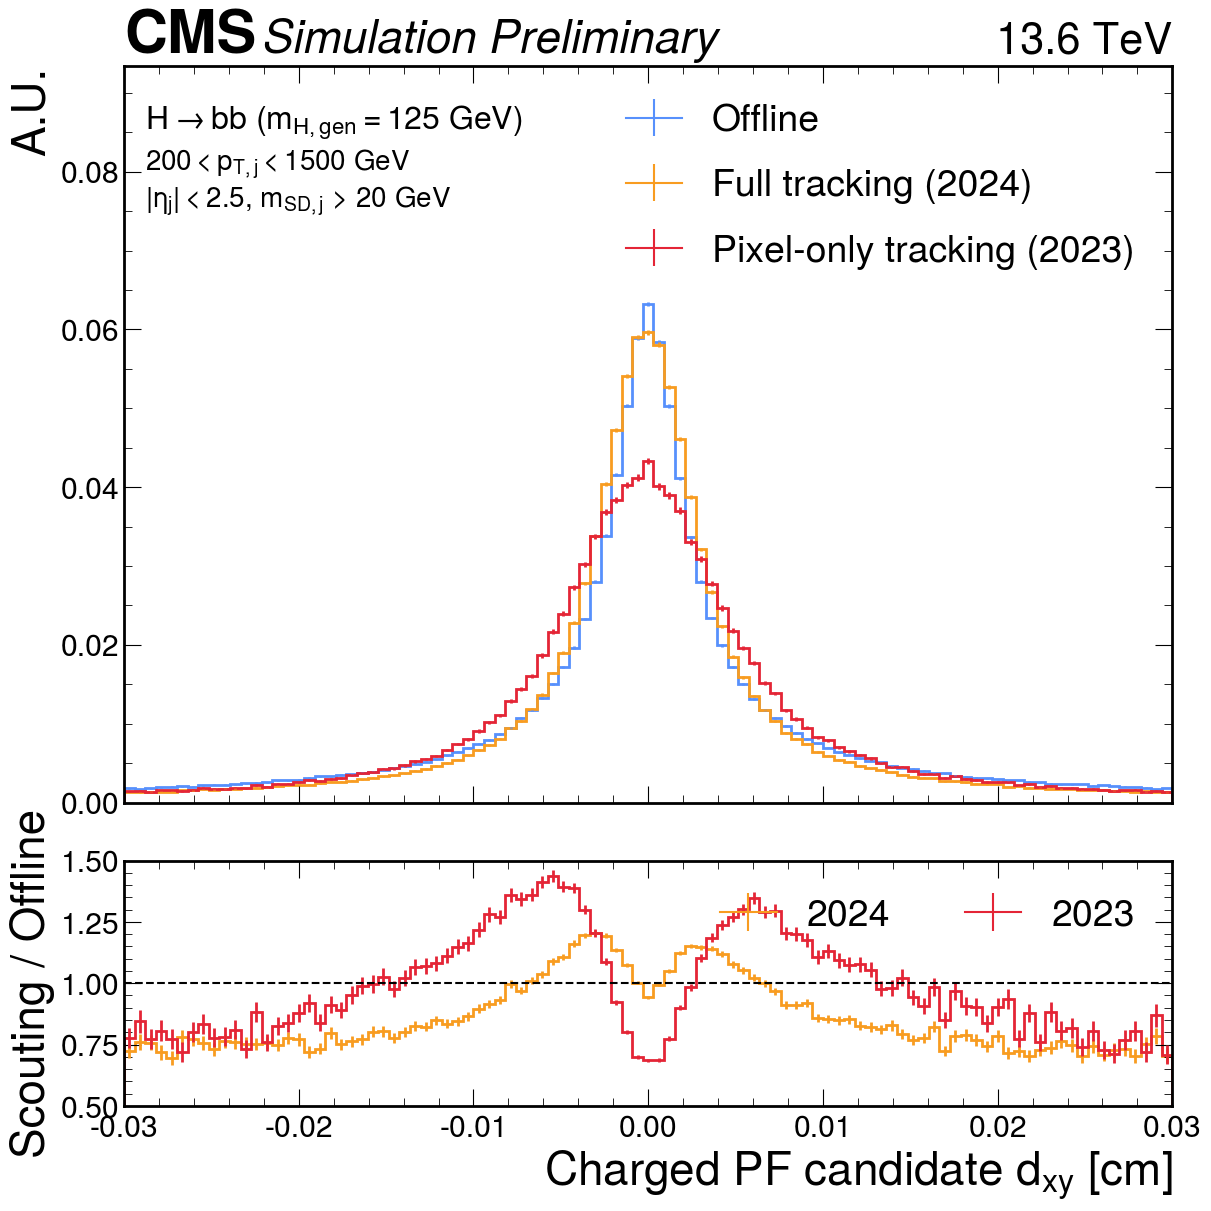

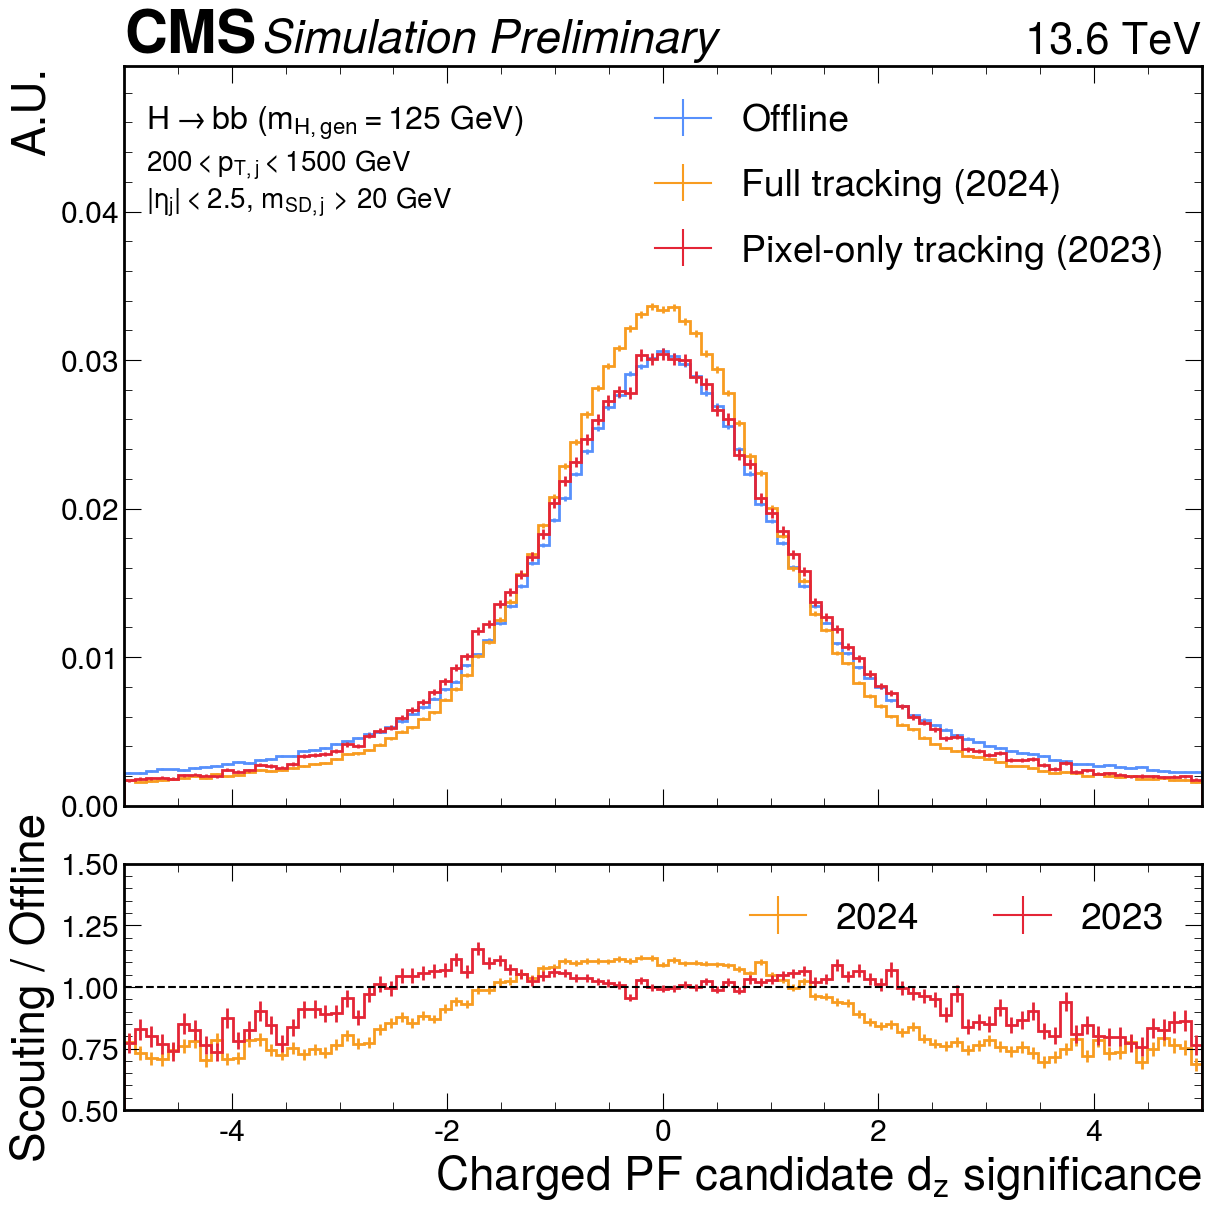

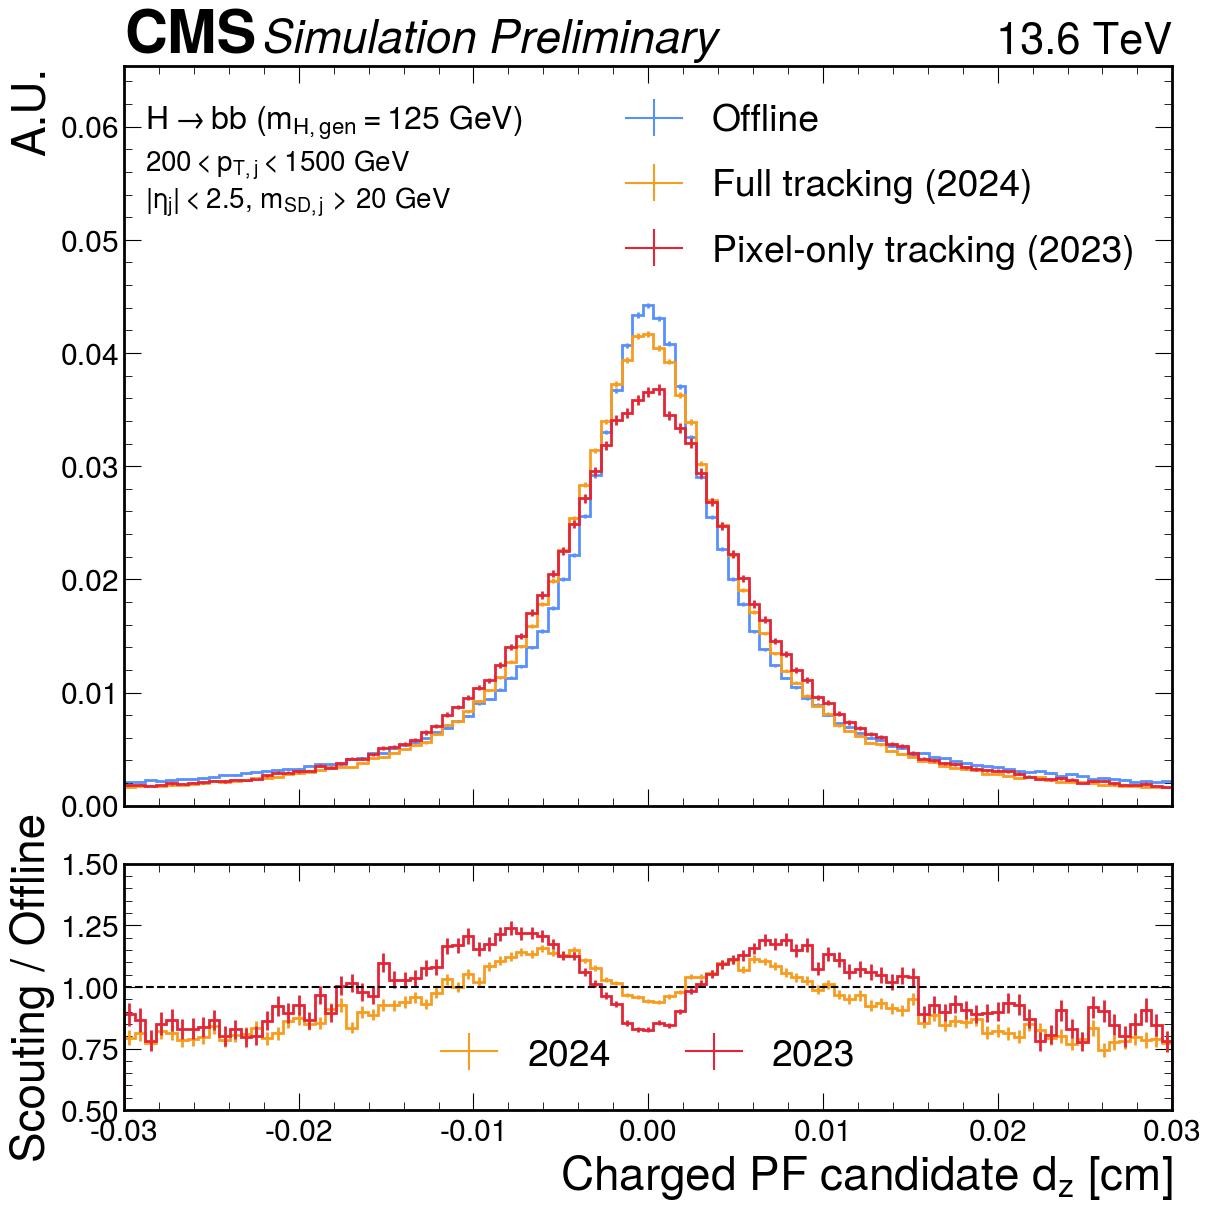

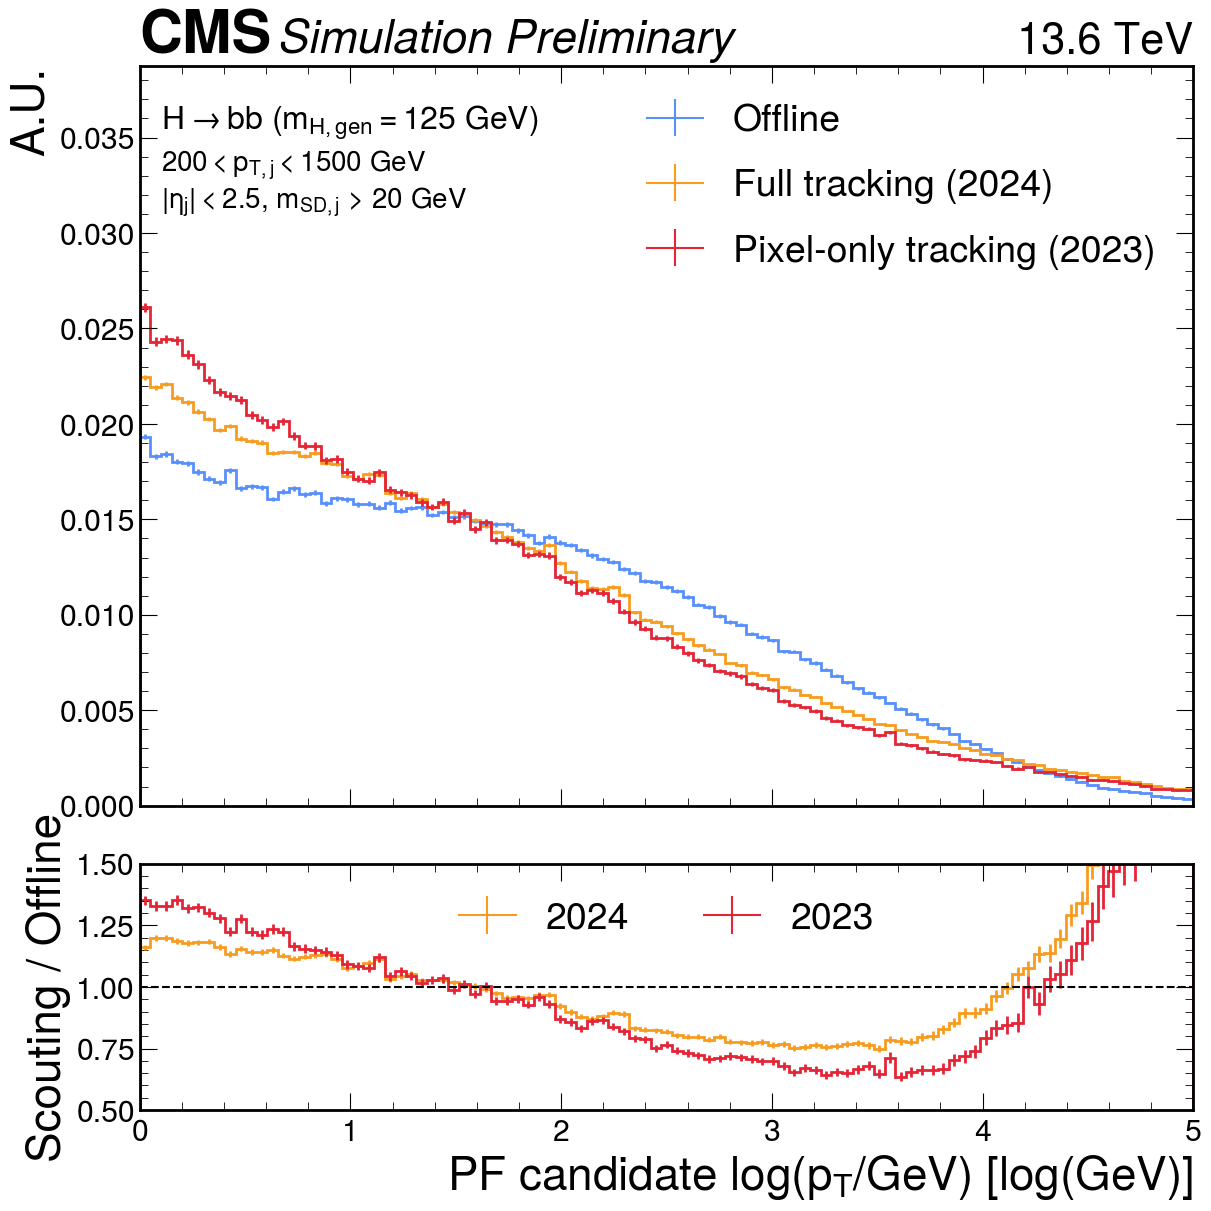

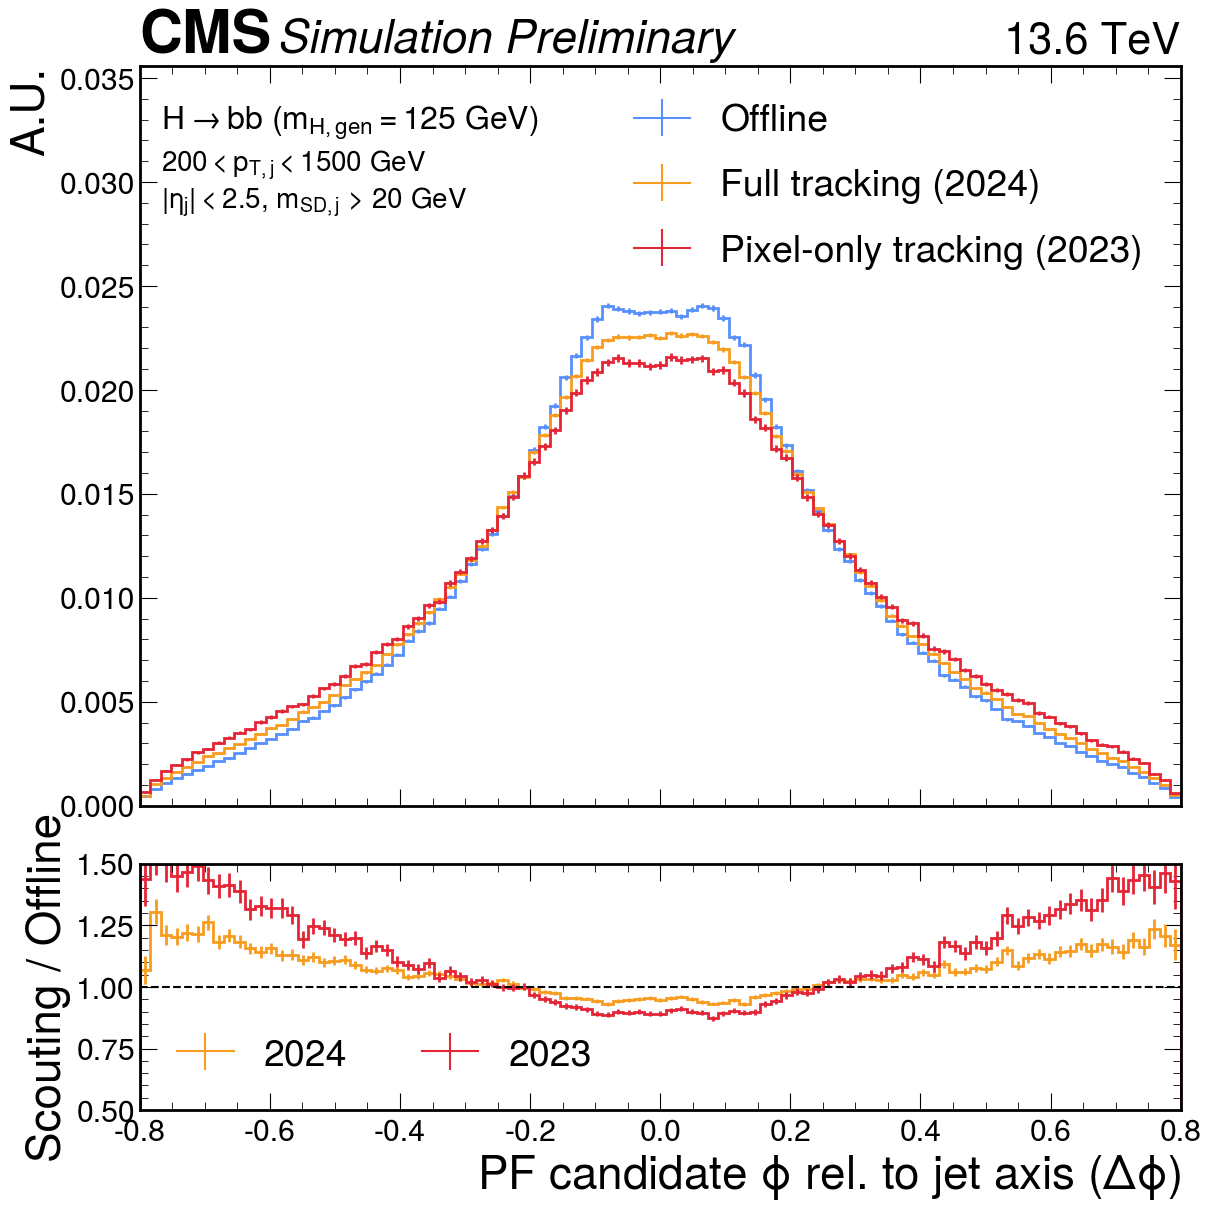

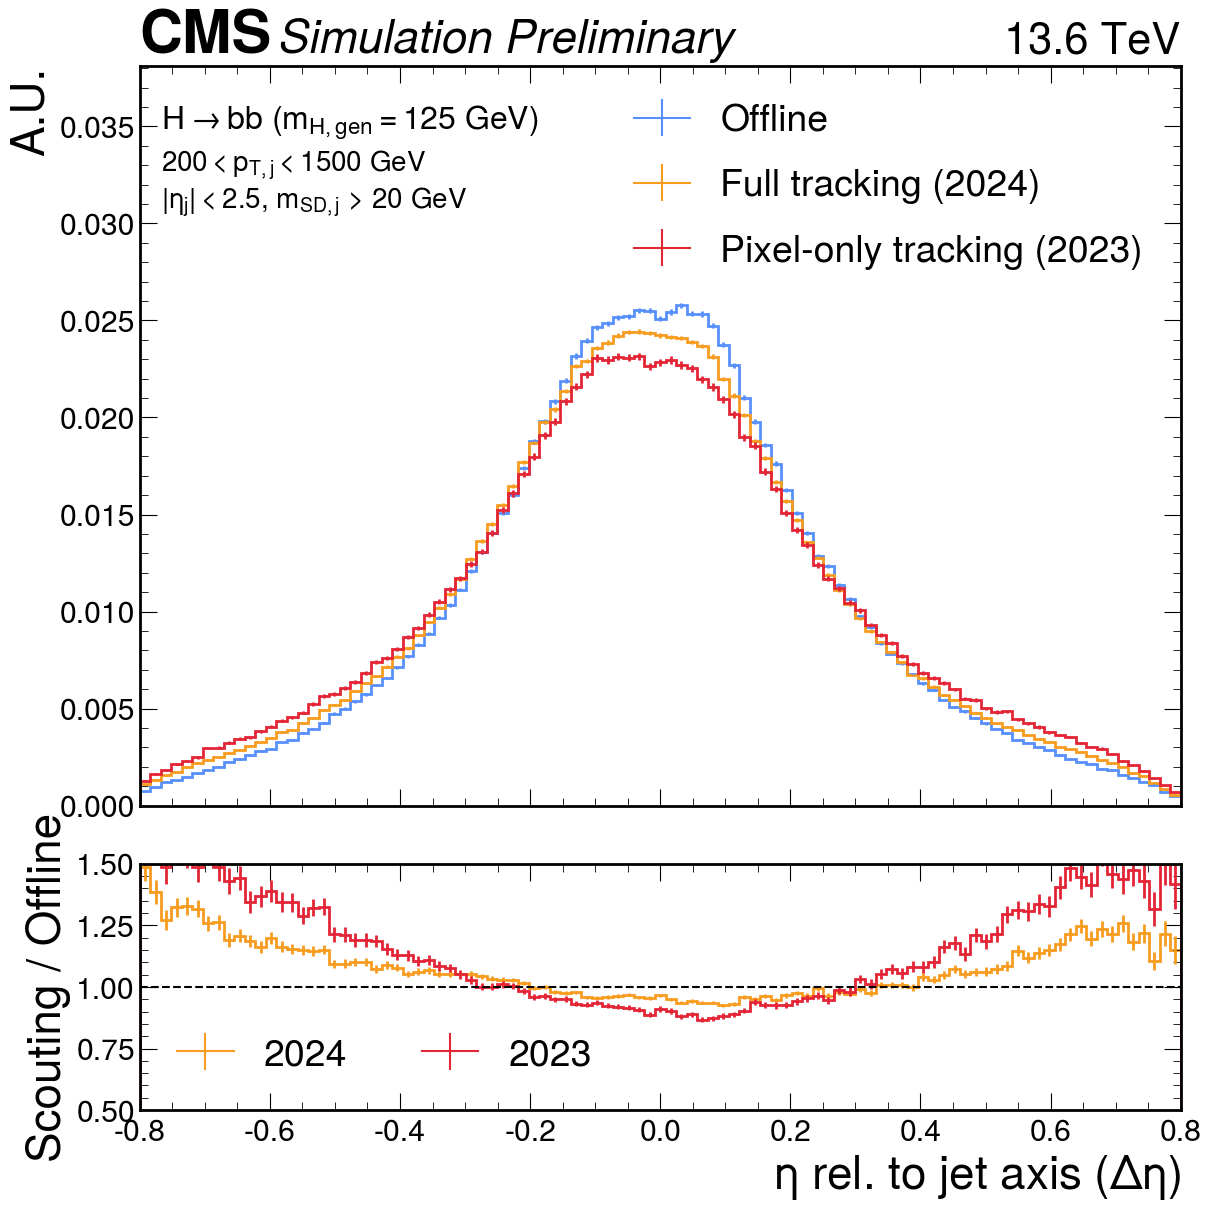

In [49]:

plotHLTAndOffline4('cpfcandlt_dxysig', 'scoutpfcand_dxysig', tree_offline, tree_hlt, tree_offline_23, tree_hlt_23, year='2024', xlabel = r'Charged PF candidate $d_{xy}$ significance', bins_= np.linspace(-5, 5, 100), outdir= 'plots_scout_ak8/input_variables_23_trial/')
plotHLTAndOffline4('cpfcandlt_dxy', 'scoutpfcand_dxy', tree_offline, tree_hlt, tree_offline_23, tree_hlt_23, year='2024', xlabel = r'Charged PF candidate $d_{xy}$ [cm]', bins_= np.linspace(-0.03, 0.03, 100), outdir= 'plots_scout_ak8/input_variables_23_trial/')
plotHLTAndOffline4('cpfcandlt_dzsig', 'scoutpfcand_dzsig', tree_offline, tree_hlt, tree_offline_23, tree_hlt_23, year='2024', xlabel = r'Charged PF candidate $d_{z}$ significance', bins_= np.linspace(-5, 5, 100), outdir= 'plots_scout_ak8/input_variables_23_trial/')
plotHLTAndOffline4('cpfcandlt_dz', 'scoutpfcand_dz', tree_offline, tree_hlt, tree_offline_23, tree_hlt_23, year='2024', xlabel = r'Charged PF candidate $d_{z}$ [cm]', bins_= np.linspace(-0.03, 0.03, 100), outdir= 'plots_scout_ak8/input_variables_23_trial/')
# plotHLTAndOffline4('cpfcandlt_e_log_nopuppi', 'scoutpfcand_e_log', tree_offline, tree_hlt, tree_offline_23, tree_hlt_23, year='2024', xlabel = r'$log(E)$ [log(GeV)]', bins_= np.linspace(0, 5, 100), outdir= 'plots_scout_ak8/input_variables_23_trial/')
plotHLTAndOffline4('cpfcandlt_pt_log_nopuppi', 'scoutpfcand_pt_log', tree_offline, tree_hlt, tree_offline_23, tree_hlt_23, year='2024', xlabel = r'PF candidate $log(p_{T}/GeV)$ [log(GeV)]', bins_= np.linspace(0, 5, 100), outdir= 'plots_scout_ak8/input_variables_23_trial/')
plotHLTAndOffline4('cpfcandlt_phirel', 'scoutpfcand_phirel', tree_offline, tree_hlt, tree_offline_23, tree_hlt_23, year='2024', xlabel = r'PF candidate $\phi$ rel. to jet axis ($\Delta\phi$)', bins_= np.linspace(-0.8, 0.8, 100), outdir= 'plots_scout_ak8/input_variables_23_trial/')
plotHLTAndOffline4('cpfcandlt_etarel', 'scoutpfcand_etarel', tree_offline, tree_hlt, tree_offline_23, tree_hlt_23, year='2024', xlabel = r'$\eta$ rel. to jet axis ($\Delta\eta$)', bins_= np.linspace(-0.8, 0.8, 100), outdir= 'plots_scout_ak8/input_variables_23_trial/')